$$\text{\huge Introduction}$$

Have you ever wanted to show a picture to someone, but only allow for the two of you to see it? One way to do so is through a visual cryptograhy scheme (VCS), which will divide an original image $\text{IC}$ into two shares, allocated to two participants. Both participants must meet in order to decode $\text{IC}$. In this particular example, we are discussing a 2 out of 2 VCS, where 2 total shares are given to 2 parties and both parties must meet in order to decode the original image. We will discuss a standard modeling for a (2,2) VCS, then demonstrate a way to represent the scheme in python code.

$$\text{\huge Modeling Our Scheme}$$                                                


In the (2,2) VCS, we will define our set of participants as $\mathcal{P}$, s.t. $\mathcal{P}$ = {1, 2}. $2^\mathcal{P}$ denotes all subsets of $\mathcal{P}$, refered to as the powerset of $\mathcal{P}$. Next we define $\Gamma_{qual} \subseteq 2^\mathcal{P}$ where $\Gamma_{qual}$ contains all sets of combined participants that must meet in order to recover the original image. $\Gamma_{qual}$ is called the set of "qualified families." The counterpart to $\Gamma_{qual}$ is $\Gamma_{forb} \subseteq 2^\mathcal{P}$, the set of "forbidden families" of $\mathcal{P}$ that cannot recover the original image, and $\Gamma_{qual} \cap \Gamma_{forb} = \emptyset$, and $\Gamma_{qual} \cup \Gamma_{forb} = 2^\mathcal{P}$. For the sake of our specific scheme: $$\Gamma_{qual} = \{\{1, 2\}\}$$ and  $$\Gamma_{forb} = \{\{1\},\{2\}\}$$ The pair ($\Gamma_{qual}, \Gamma_{forb}$) is reffered to as the access structure of the scheme. This means that $\forall X \in \Gamma_{qual}$, $\text{IC}$ can be recovered, and $\forall X \in \Gamma_{forb}$, $\text{IC}$ cannot be recovered. each $ p \in \mathcal{P}$, will receive a share of each pixel of the orignal image assigned uniformly at random. In the case of the (2,2) VCS, particpants 1 and 2 are uniformly at random allocated an encoded pixel for all of the original pixels in the original image. Each pixel is represented by 4  black and white subpixels, which can be further represented by a binary matrix $M$, where a 1 represents a black subpixel and a 0 represents a white subpixel. In our scheme, each pixel's orientation will be either a "black" orientation $b$ or a "white" orientation $w$, while schemes with a larger amount of particpants may contain more orientations. We also want the relative difference $\alpha$ and the contrast $\alpha \cdot 4$ to be as large as possible, constituting a VCS that can be visually recognized with minimal "fuzziness." In this case with two orientations of pixels, $\alpha = \frac{1}{4}$ and $\alpha \cdot m = \frac{1}{4} \cdot 4 = 1$. The relative difference, and therefore the contrast, can be calculated easily be comparing the number of black or white pixels to a pixel of a given share. Finally, to model each pixel so that we can recover the original image through overlaying, the orientations are done in a special way. A $b$ pixel's matrix representation is: $$\begin{pmatrix} 1 &0\\ 0 &1 \end{pmatrix}$$ and a $w$ pixel's matrix representation is: $$\begin{pmatrix} 0 &1\\ 1 &0 \end{pmatrix}$$ The participant matrix $M$ is a $|\mathcal{P}|$ x 4 matrix representing each participant's randomly assigned pixel for all pixels in the image. Each row $i$ is a row condensed form of the $b$ or $w$ binary matrix. For example, if particpant 1 received a $b$ pixel and participant 2 received a $w$ pixel, the $M$ matrix would be: $$\begin{pmatrix} 1 &0 &0 &1 \\ 0 &1 &1 &0 \end{pmatrix}$$ Utilizing the shares of both participants, we can decrypt the original image through overlaying the shares of participants in qualifying sets.



$$\text{\huge Decoding}$$

When the two particpants meet, the decoding of the original image is done by the human visual system by overlaying the shares. However to represent this mathematically, we will use a form of matrix addition. The summation of two matrices is s.t. if the binary matrices are equivalent: $$\begin{pmatrix} 1 &0\\ 0 &1 \end{pmatrix} + \begin{pmatrix} 1 &0\\ 0 &1 \end{pmatrix} = \begin{pmatrix} 1 &0\\ 0 &1 \end{pmatrix}$$ $$\begin{pmatrix} 0 &1\\ 1 &0 \end{pmatrix} + \begin{pmatrix} 0 &1\\ 1 &0 \end{pmatrix} = \begin{pmatrix} 0 &1\\ 1 &0 \end{pmatrix}$$ and when the matrixces are different: $$\begin{pmatrix} 1 &0\\ 0 &1 \end{pmatrix} + \begin{pmatrix} 0 &1\\ 1 &0 \end{pmatrix} = \begin{pmatrix} 1 &1\\ 1 &1 \end{pmatrix}$$ The resulting matrices contain all 1's or 1's and zeros, creating a contrast between two pixels two enable for seeing a black pixel or a white pixel that has a slightly grey color. Given knowledge on one of the shares and orientations, we are unable to decode the original pixel. To prove this, we will analyze the security of the scheme.

$$\text{\huge Security}$$

Now that we have demonstrated how to decode our image, we must next prove that it is secure. Consider a (2,2) VCS scheme with particpants $p_1$ and $p_2$ and an original image OI that is currently unknown. Let $S$ be a random variable of the set $\{b, w\}$. Then $p_1$'s first pixel $a$ and $p_2$'s first pixel $c$ are each either $b$ oriented or $w$ oriented such that $P_r[S = a] = \frac{1}{2}$ and $P_r[S = c] = \frac{1}{2}$. We want to show that for either pixel, $P_r[S = a | S = c]$ = $\frac{1}{2}$. First, let us consider $P_r[a = b]$. We can expand this using Baye's Theorem: $$P_r[a = b] = P_r[a = b|c = b] \cdot P_r[c = b] + P_r[a = b|c = w] \cdot P_r[c = w]$$ Since $P_r[S = a] = \frac{1}{2}$ and $P_r[S = c] = \frac{1}{2}$, we can rewrite the equation as $$P_r[a = b] = P_r[a = b|c = b] \cdot \frac{1}{2}  + P_r[a = b|c = w] \cdot \frac{1}{2}$$  $$= \frac{1}{2}(P_r[a = b|c = b] + P_r[a = b|c = w])$$ $$= \frac{1}{2} (1)$$ $$= \frac{1}{2}$$ As shown, the probability of $p_1$'s first pixel being $b$ oriented does not change when the orientation of $p_2$'s first pixel is known. This process can be repeated for the remaining values of $a$ and $c$ to encompass the entire scheme, where each will equal $\frac{1}{2}$. Thus, our scheme is both secure and decodable.

$$\text{\huge Coding}$$

Although there is mathematical insight behind a VCS, the real beauty of it lies in the visual implementation. One way to demonstrate this is through a Python based program. What we first need to do is import the Image module from PIL, and the random module. Ensure that Pillow is installed before proceeding, and that your choice of image is in black and white. 

In [5]:
from PIL import Image
import random

This will enable us to handle our image. What we will next do is define a function to place a black or white pixel into each share, using the specified x and y value and corresponding pixel values.

In [6]:
#places the pixel values corresponding to the share at the specified height and width
def place_image_pixels(share1, share2, pixel1, pixel2, width, height):

    #place share1's pixels in the binary matrix
    share1.putpixel((width * 2, height * 2), pixel1[0][0])
    share1.putpixel((width * 2 + 1, height * 2), pixel1[1][0])
    share1.putpixel((width * 2, height * 2 + 1), pixel1[0][1])
    share1.putpixel((width * 2 + 1, height * 2 + 1), pixel1[1][1])

    #place share1's pixels in the binary matrix
    share2.putpixel((width * 2, height * 2), pixel2[0][0])
    share2.putpixel((width * 2 + 1, height * 2), pixel2[1][0])
    share2.putpixel((width * 2, height * 2 + 1), pixel2[0][1])
    share2.putpixel((width * 2 + 1, height * 2 + 1), pixel2[1][1])

This function randomly chooses using the choose method from the random module which share receives which color of pixel. It distinuishes if they receive the same color or not to ensure the recovered image will be formed properly in the previously defined recovery function.

In [7]:
#randomly allocate the two images and place pixels accordingly
def allocate_images(image_path, share1_path, share2_path):
    
    #opens the original image in binary format that creates two new shares 
    #such that the pixels can be represented in boolean matrix form
    img = Image.open(image_path).convert("1")  # open in binary mode
    width, height = img.size
    share1 = Image.new("1", (width * 2, height * 2))
    share2 = Image.new("1", (width * 2, height * 2))

    #define black and white boolean matrices
    white_pixel = [(0, 1), (1, 0)]
    black_pixel = [(1, 0), (0, 1)]

    #loop through pixels in original image
    for x in range(width):
        for y in range(height):

            #get the original pixel
            pixel = img.getpixel((x, y))

            #randomly choose between 1 and 0 (black and white)
            option = random.choice([0,1])

            #if the pixel is 1 (white), choose randomly to make both shares have the same pixel 
            #value, being either black or white
            if pixel:
            # Draw the encrypted subpixels on the shares
                if option: 
                    place_image_pixels(share1, share2, white_pixel, white_pixel, x, y)
                else:
                    place_image_pixels(share1, share2, black_pixel, black_pixel, x, y)
            #otherwise, randomly assign each share with the opposite pixel color of the other one.        
            else:
                if option:
                    place_image_pixels(share1, share2, white_pixel, black_pixel, x, y)
                else:
                    place_image_pixels(share1, share2, black_pixel, white_pixel, x, y)

    #save the new shares
    share1.save(share1_path)
    share2.save(share2_path)

Now let us define the last function to decrypt the images. Doing so will reveal the original image with a lower contrast as the modified black and white pixel structures are slightly grey in color, however to the naked eye the contrast is barely noticeable. 

In [8]:
#computational representation of the recover function
def recover_images(share1_path, share2_path, decrypted_path):
    
    #open both shares in binary mode, and get the dimensions for reference
    share1 = Image.open(share1_path).convert("1")
    share2 = Image.open(share2_path).convert("1")
    width, height = share1.size

    #declare new image to overlay shares and decrypt
    decrypted_img = Image.new("1", (width, height))

    #iterate through pixels in both shares
    for x in range(width):
        for y in range(height):

            #get the corresponding pixels of both shares
            pixel1 = share1.getpixel((x, y))
            pixel2 = share2.getpixel((x, y))
            # overlay pixels
            if not pixel1 or not pixel2:
                decrypted_pixel = 1
            else:
                decrypted_pixel = 0
            #place the new pixel in the spot in the decrypted image
            decrypted_img.putpixel((x, y), decrypted_pixel)
    
    #save the image
    decrypted_img.save(decrypted_path)

You can give this a try by running the encrypt function first on a binary image, and then the decrypt function on the two shares created from encryption. An example image is provided to test the functions on, first by encrypting the image into two shares then decrypting those two shares back to the original image. Below we will demonstrate it in action based on an example image:

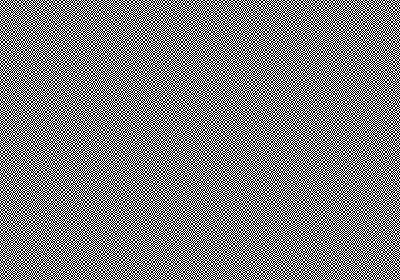

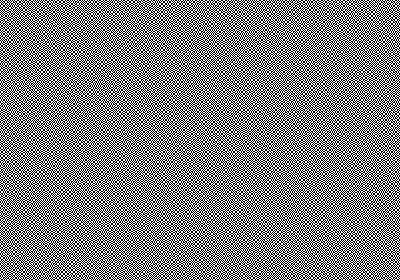

In [10]:
input_image = "Neighborhood_watch_bw.png"

allocate_images(input_image, "share1.png", "share2.png")

share1 = Image.open("share1.png")
share2 = Image.open("share2.png")

display(share1)
display(share2)

Above are the two shares created from splitting the original image randomly. If a person were to gain access to one share, they would not be able to deduce the original image from that share alone. Next we will take the two shares and perform an overlay to recover the original image.

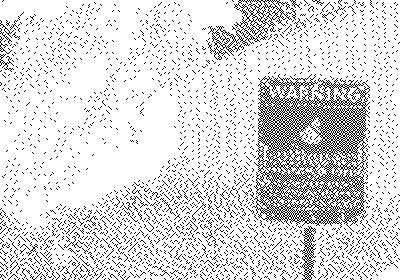

In [11]:
recover_images("share1.png", "share2.png", "decrypted_image.png")

overlay = Image.open("decrypted_image.png")

display(overlay)

The resulting overlay is provided above. Although the original image is mostly distinguishable, some slight recovery error results from attempting to convert a 1x1 pixel to a 2x2 pixel and then back to a 1x1. 